## Problem 1

In [1]:
%pip -q install pygad matplotlib numpy pandas


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pygad
import matplotlib.pyplot as plt
import pandas as pd
import random

In [ ]:

def generate_knapsack_instance(n_items, seed=0):
    random.seed(seed)
    
    weights = [random.randint(1, 15) for _ in range(n_items)]
    values  = [random.randint(1, 30) for _ in range(n_items)]
    
    # 取总重量的 30%~50% 之间的才能用
    total_w = sum(weights)
    capacity = int(total_w * random.uniform(0.3, 0.5))
    
    return weights, values, capacity

# 小测试
weights, values, capacity = generate_knapsack_instance(10, seed=1)
weights, values, capacity

def make_fitness_func(weights, values, capacity):
    n = len(weights)
    
    def fitness_func(ga_instance, solution, solution_idx):
        picked = [1 if x >= 0.5 else 0 for x in solution]
        
        total_w = 0
        total_v = 0
        for i in range(n):
            if picked[i] == 1:
                total_w += weights[i]
                total_v += values[i]
        
        if total_w > capacity:
            return 0  # too much
        return total_v
    
    return fitness_func

# print(total_w)
# print(total_v)
#print(make_fitness_func)


# My case
n_items = 20
weights, values, capacity = generate_knapsack_instance(n_items, seed=2)

fitness_func = make_fitness_func(weights, values, capacity)

ga = pygad.GA(
    num_generations=50,
    num_parents_mating=8,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=n_items,
    gene_space=[0, 1],     
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10
)

ga.run()

solution, solution_fitness, solution_idx = ga.best_solution()
print(solution_fitness)


picked = [1 if x >= 0.5 else 0 for x in solution]

total_w = sum(w for w, p in zip(weights, picked) if p == 1)
total_v = sum(v for v, p in zip(values, picked) if p == 1)

print("capacity =", capacity)
print("total weight =", total_w)
print("total value  =", total_v)
print("picked items =", picked)

def run_once(weights, values, capacity, num_generations, mutation_percent_genes, seed=0):
    random.seed(seed)
    fitness_func = make_fitness_func(weights, values, capacity)

    ga = pygad.GA(
        num_generations=num_generations,
        num_parents_mating=8,
        fitness_func=fitness_func,
        sol_per_pop=20,
        num_genes=len(weights),
        gene_space=[0, 1],
        mutation_type="random",
        mutation_percent_genes=mutation_percent_genes
    )
    ga.run()
    _, best_fit, _ = ga.best_solution()
    return best_fit

tests = []
for gens in [10, 20, 30, 40]:
    for mut in [5, 10, 20]:
        best = run_once(weights, values, capacity, gens, mut, seed=1)
        tests.append((gens, mut, best))

print(tests)

print("second time:")

testsII = []
for gens in [50, 60, 70, 80]:
    for mut in [5, 10, 20]:
        best = run_once(weights, values, capacity, gens, mut, seed=1)
        testsII.append((gens, mut, best))

print(testsII)


all_tests = tests + testsII

all_tests_sorted = sorted(all_tests, key=lambda x: x[2], reverse=True)
best_value = all_tests_sorted[0][2]

print("gens | mutation | best_value")
print("-" * 30)

for gens, mut, val in all_tests_sorted:
    mark = " **" if val == best_value else ""
    print(f"{gens:4d} | {mut:8d} | {int(val):10d}{mark}")


251
capacity = 78
total weight = 77
total value  = 251
picked items = [0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0]
[(10, 5, np.int64(245)), (10, 10, np.int64(248)), (10, 20, np.int64(217)), (20, 5, np.int64(247)), (20, 10, np.int64(235)), (20, 20, np.int64(232)), (30, 5, np.int64(251)), (30, 10, np.int64(249)), (30, 20, np.int64(230)), (40, 5, np.int64(252)), (40, 10, np.int64(252)), (40, 20, np.int64(236))]
second time:
[(50, 5, np.int64(234)), (50, 10, np.int64(239)), (50, 20, np.int64(240)), (60, 5, np.int64(251)), (60, 10, np.int64(248)), (60, 20, np.int64(242)), (70, 5, np.int64(252)), (70, 10, np.int64(252)), (70, 20, np.int64(238)), (80, 5, np.int64(252)), (80, 10, np.int64(249)), (80, 20, np.int64(251))]
gens | mutation | best_value
------------------------------
  40 |        5 |        252 **
  40 |       10 |        252 **
  70 |        5 |        252 **
  70 |       10 |        252 **
  80 |        5 |        252 **
  30 |        5 |        251
  60 |       

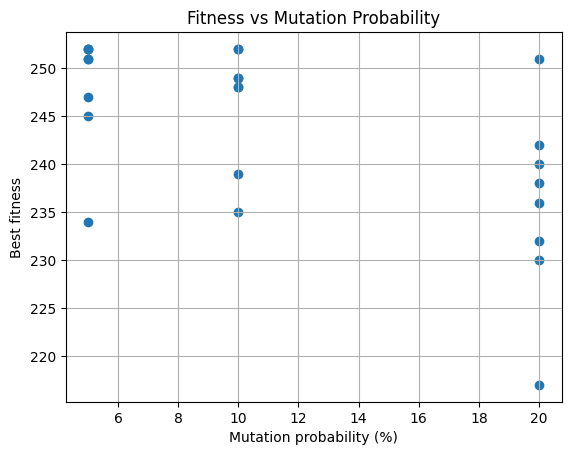

In [19]:
##visuilization 
results = []

for gens, mut, val in all_tests:
    results.append({
        "num_generations": gens,
        "mutation_probability": mut,
        "fitness": int(val)
    })

fitness = [r["fitness"] for r in results]
mutation = [r["mutation_probability"] for r in results]

plt.figure()
plt.scatter(mutation, fitness)
plt.xlabel("Mutation probability (%)")
plt.ylabel("Best fitness")
plt.title("Fitness vs Mutation Probability")
plt.grid(True)
plt.show()



In [ ]:
##Do you think the genetic algorithm is suitable for this scenario?
#Yes, i think the result is good enough for this problem, 
#this type of knapsack problem aren not that demanded for a super accurate result.
#The 'fast' feature of the algorthim is very useful in this scenario.

## Problem 2

In [ ]:
import random
import copy
def print_board(board):

    print("-------------------------")
    
    for i in range(9):
        line = "| "  
        
        for j in range(9):
            val = board[i][j]

            if val == 0:
                line = line + ". "
            else:
                line = line + str(val) + " "

            if j == 2 or j == 5 or j == 8:
                line = line + "| "
        
        print(line)

        if i == 2 or i == 5:
            print("-------------------------")
            
    print("-------------------------")


def making_fixed_map(initial_board):
    fixed = []
    for i in range(9):
        row_bools = []
        for j in range(9):
            if initial_board[i][j] != 0:
                row_bools.append(True)
            else:
                row_bools.append(False)
        fixed.append(row_bools)
    
    return fixed


def calculate_fitness(board):
    errors = 0
    #col
    for j in range(9):
        col_list = []
        for i in range(9):
            col_list.append(board[i][j])
            
        for num in range(1, 10):
            count = col_list.count(num)
            if count > 1:
                errors = errors + (count - 1)
    #print(col_list)

    start_points = [0, 3, 6]
    
    for r_start in start_points:
        for c_start in start_points:
            
            temp_box = []
            for r in range(r_start, r_start + 3):
                for c in range(c_start, c_start + 3):
                    temp_box.append(board[r][c])
            
            for num in range(1, 10):
                c_num = temp_box.count(num)
                if c_num > 1:
                    errors = errors + (c_num - 1)
                    
    return errors

def create_individual(initial_board):
    new_board = copy.deepcopy(initial_board)
    for r in range(9):
        existing = set([x for x in new_board[r] if x != 0])
        missing = [x for x in range(1, 10) if x not in existing]
        random.shuffle(missing)
        
        idx = 0
        for c in range(9):
            if new_board[r][c] == 0:
                new_board[r][c] = missing[idx]
                idx += 1
    return new_board

def create_population(size, initial_board):
    population = []
    for _ in range(size):
        population.append(create_individual(initial_board))
    return population


def crossover(parent1, parent2):
    crossover_point = random.randint(1, 8) # 在第1到8行之间切一刀
    

    child_board = []
    for r in range(crossover_point):
        child_board.append(list(parent1[r])) # copy the list

    for r in range(crossover_point, 9):
        child_board.append(list(parent2[r]))
        
    return child_board

def mutate(board, locked, rate=0.1):
    new_board = copy.deepcopy(board)

    for r in range(9):

        if random.random() > rate:
            continue

        cols = [c for c in range(9) if not locked[r][c]]

        if len(cols) >= 2:
            a, b = random.sample(cols, 2)
            new_board[r][a], new_board[r][b] = new_board[r][b], new_board[r][a]

    return new_board

def tournament_selection(population, scores, k=3):
    selection_pool = []
    pool_scores = []
    
    for i in range(k):
        rand_idx = random.randint(0, len(population) - 1)
        selection_pool.append(population[rand_idx])
        pool_scores.append(scores[rand_idx])
    
    best_score = pool_scores[0]
    best_individual = selection_pool[0]
    
    for i in range(k):
        if pool_scores[i] < best_score:
            best_score = pool_scores[i]
            best_individual = selection_pool[i]
            
    return best_individual


def solve_sudoku_ga(initial_board):
    POP_SIZE = 200        
    MAX_GENERATIONS = 1000 
    MUTATION_RATE = 0.1   
    fixed_map = making_fixed_map (initial_board)
    population = create_population(POP_SIZE, initial_board)
    
    print(f"GA Started: PopSize={POP_SIZE}, MaxGen={MAX_GENERATIONS}")
    
    for generation in range(MAX_GENERATIONS):
        scores = [calculate_fitness(ind) for ind in population]
        min_score = min(scores)
        best_index = scores.index(min_score)
        best_individual = population[best_index]

        #if generation % 50 == 0 or min_score == 0:
            #print(f"Gen {generation}: Best Conflict Score = {min_score}")
        
        if min_score == 0:
            return best_individual, 0 
        
        new_population = []
        

        while len(new_population) < POP_SIZE:
 
            p1 = tournament_selection(population, scores)
            p2 = tournament_selection(population, scores)
            
            child = crossover(p1, p2)
            

            child = mutate(child, fixed_map, MUTATION_RATE)
            
            new_population.append(child)
            
        population = new_population
        
    return best_individual, min(scores)

if __name__ == "__main__":
    puzzle = [
        [5, 3, 0, 0, 7, 0, 0, 0, 0],
        [6, 0, 0, 1, 9, 5, 0, 0, 0],
        [0, 9, 8, 0, 0, 0, 0, 6, 0],
        [8, 0, 0, 0, 6, 0, 0, 0, 3],
        [4, 0, 0, 8, 0, 3, 0, 0, 1],
        [7, 0, 0, 0, 2, 0, 0, 0, 6],
        [0, 6, 0, 0, 0, 0, 2, 8, 0],
        [0, 0, 0, 4, 1, 9, 0, 0, 5],
        [0, 0, 0, 0, 8, 0, 0, 7, 9]
    ]

    print("Initial board:")
    print_board(puzzle)
 
    

    solution, conflict = solve_sudoku_ga(puzzle)
    

    print(f"Best found (objective = {conflict})")
    print_board(solution)

Initial board:
-------------------------
| 5 3 . | . 7 . | . . . | 
| 6 . . | 1 9 5 | . . . | 
| . 9 8 | . . . | . 6 . | 
-------------------------
| 8 . . | . 6 . | . . 3 | 
| 4 . . | 8 . 3 | . . 1 | 
| 7 . . | . 2 . | . . 6 | 
-------------------------
| . 6 . | . . . | 2 8 . | 
| . . . | 4 1 9 | . . 5 | 
| . . . | . 8 . | . 7 9 | 
-------------------------
GA Started: PopSize=200, MaxGen=1000
Best found (objective = 6)
-------------------------
| 5 3 2 | 6 7 8 | 4 9 1 | 
| 6 7 4 | 1 9 5 | 3 2 8 | 
| 1 9 8 | 3 4 2 | 5 6 7 | 
-------------------------
| 8 1 5 | 9 6 4 | 7 2 3 | 
| 4 2 6 | 8 7 3 | 9 5 1 | 
| 7 3 9 | 5 2 1 | 8 4 6 | 
-------------------------
| 9 6 1 | 7 3 5 | 2 8 4 | 
| 2 8 7 | 4 1 9 | 6 3 5 | 
| 3 5 4 | 2 8 6 | 1 7 9 | 
-------------------------


## Problem 3

In [40]:
import random
import math

def get_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def calculate_total_distance(route):
    total = 0
    for i in range(len(route) - 1):
        total += get_distance(route[i], route[i+1])
    return total

def generate_random_points(num_points):
    points = []
    for _ in range(num_points):
        x = random.randint(0, 100)
        y = random.randint(0, 100)
        points.append((x, y))
    return points

def generate_special_scenario():
    points = []
    for i in range(5):
        points.append((10, 10 + i*5))
    for i in range(5):
        points.append((50, 50 + i*5))
    for i in range(5):
        points.append((90, 10 + i*5))
    return points

def greedy_algorithm(points):
    if not points:
        return []
    
    unvisited = points[:]
    current_pos = unvisited[0]
    path = [current_pos]
    unvisited.remove(current_pos)
    
    while unvisited:
        nearest_point = None
        min_dist = 999999999
        
        for point in unvisited:
            dist = get_distance(current_pos, point)
            if dist < min_dist:
                min_dist = dist
                nearest_point = point
        
        path.append(nearest_point)
        current_pos = nearest_point
        unvisited.remove(nearest_point)
        
    return path

def two_opt_optimization(route):
    best_route = route[:]
    keepgoing = True
    
    while keepgoing:
        keepgoing = False
        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route)):
                if j - i == 1:
                    continue
                
                new_route = best_route[:]
                new_route[i:j] = best_route[i:j][::-1]
                
                if calculate_total_distance(new_route) < calculate_total_distance(best_route):
                    best_route = new_route
                    keepgoing = True
                    
    return best_route

def three_opt_optimization(route):
    best_route = route[:]
    n = len(route)
    keepgoing = True
    
    while keepgoing:
        keepgoing = False
        for i in range(1, n - 4):
            for j in range(i + 2, n - 2):
                for k in range(j + 2, n):
                    
                    segments = [
                        best_route[i:j],
                        best_route[j:k],
                        best_route[k:] + best_route[:i] 
                    ]
                    
                    new_route = best_route[:i] + segments[1] + segments[0] + best_route[k:]
                    
                    if calculate_total_distance(new_route) < calculate_total_distance(best_route):
                        best_route = new_route
                        keepgoing = True
    return best_route



#1
points = generate_random_points(20)
print(f"generted {len(points)} random locations.")

#2
greedy_route = greedy_algorithm(points)
greedy_dist = calculate_total_distance(greedy_route)
print(f"Greedy Heuristic distances: {greedy_dist:.2f}")

#3
route_2opt = two_opt_optimization(greedy_route)
dist_2opt = calculate_total_distance(route_2opt)
print(f"2-opt Optimized Distance: {dist_2opt:.2f}")

#4
route_3opt = three_opt_optimization(greedy_route)
dist_3opt = calculate_total_distance(route_3opt)
print(f"3-opt Optimized distance: {dist_3opt:.2f}")

#7
print("-" * 30)
print("result:")
print(f"improved from 2-opt: {greedy_dist - dist_2opt:.2f}")
print(f"improved from 3-opt: {greedy_dist - dist_3opt:.2f}")

if dist_3opt < dist_2opt:
    print("3-opt is better")
else:
    print("2-opt is better.")

generted 20 random locations.
Greedy Heuristic distances: 390.06
2-opt Optimized Distance: 370.54
3-opt Optimized distance: 374.33
------------------------------
result:
improved from 2-opt: 19.52
improved from 3-opt: 15.73
2-opt is better.
